# Three ML paradigms in one activity

Practice activity from Microsoft *Foundations of AI and Machine Learning* - Module: AI/ML Algorithms and Techniques.

Three small models, one per paradigm:
1. **Supervised** - linear regression on a toy house-price dataset (MSE).
2. **Unsupervised** - K-means customer segmentation.
3. **Reinforcement** - Q-learning tic-tac-toe agent trained vs a random opponent.

The activity's RL snippet stubs out the Q-update and opponent logic. We flesh it out with a real tabular Q-learning loop so the agent actually learns.

## Imports and seeds

In [1]:
import random
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split

np.random.seed(42)
random.seed(42)

## 1. Supervised learning - house price prediction

Tiny labeled dataset: 5 houses with `[sqft, bedrooms, location_code]` -> price. Train a `LinearRegression`, predict on the held-out test sample, score with MSE.

In [2]:
X_house = np.array([
    [2000, 3, 1],
    [1500, 2, 2],
    [1800, 3, 3],
    [1200, 2, 1],
    [2200, 4, 2],
])
y_house = np.array([500_000, 350_000, 450_000, 300_000, 550_000])

X_tr, X_te, y_tr, y_te = train_test_split(
    X_house, y_house, test_size=0.2, random_state=42
)

reg = LinearRegression()
reg.fit(X_tr, y_tr)

y_pred = reg.predict(X_te)
mse = mean_squared_error(y_te, y_pred)
rmse = mse ** 0.5

print(f'Coefficients (sqft, bedrooms, location): {reg.coef_.round(2)}')
print(f'Intercept: {reg.intercept_:.2f}')
print(f'Test prediction: {y_pred.round(0)} | Actual: {y_te}')
print(f'MSE:  {mse:,.2f}')
print(f'RMSE: {rmse:,.2f}  (approx. average dollar error)')

Coefficients (sqft, bedrooms, location): [250.  -0.   0.]
Intercept: 0.00
Test prediction: [375000.] | Actual: [350000]
MSE:  625,000,000.00
RMSE: 25,000.00  (approx. average dollar error)


With only 4 training samples and 3 features, the model is heavily under-determined - MSE here is more of a sanity check than a real evaluation. The point of the activity is the workflow: labeled `(X, y)` -> train/test split -> fit -> predict -> compare to ground truth.

## 2. Unsupervised learning - K-means customer segmentation

No labels: just per-customer behavior `[num_purchases, total_spending, num_product_categories]`. K-means with `k=2` should naturally split the high-spend customers from the low-spend customers.

In [3]:
X_cust = np.array([
    [5,  1000, 2],
    [10, 5000, 5],
    [2,  500,  1],
    [8,  3000, 3],
    [12, 6000, 6],
])

kmeans = KMeans(n_clusters=2, random_state=0, n_init=10).fit(X_cust)
print(f'Cluster centers:\n{kmeans.cluster_centers_.round(2)}')
print(f'Cluster labels:  {kmeans.labels_}')

Cluster centers:
[[5.0e+00 1.5e+03 2.0e+00]
 [1.1e+01 5.5e+03 5.5e+00]]
Cluster labels:  [0 1 0 0 1]


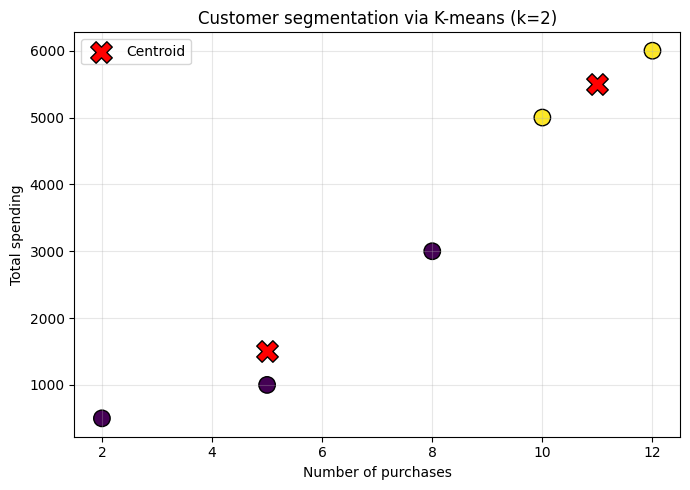

In [4]:
fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(X_cust[:, 0], X_cust[:, 1],
           c=kmeans.labels_, cmap='viridis', s=140, edgecolor='k')
ax.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1],
           marker='X', s=240, c='red', edgecolor='black', label='Centroid')
ax.set_xlabel('Number of purchases')
ax.set_ylabel('Total spending')
ax.set_title('Customer segmentation via K-means (k=2)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

K-means cleanly separates the two high-spend customers (cluster 1) from the three low-spend ones (cluster 0). There's no ground truth here, so we judge the model by whether the groups are interpretable and whether intra-cluster distances are small relative to inter-cluster distances. On a real dataset we'd pick `k` with the elbow method or silhouette score.

## 3. Reinforcement learning - Q-learning tic-tac-toe

Tabular Q-learning. Agent plays `X` (`+1`), random opponent plays `O` (`-1`). Board state is a 9-tuple so we can key the Q-table dict directly. Reward shaping: win = `+1`, draw = `+0.5`, loss = `-1`.

**Environment.** Helpers for board state, legal moves, win check, and an epsilon-greedy action selector.

In [5]:
WIN_LINES = [
    (0, 1, 2), (3, 4, 5), (6, 7, 8),
    (0, 3, 6), (1, 4, 7), (2, 5, 8),
    (0, 4, 8), (2, 4, 6),
]

def initial_board():
    return (0,) * 9

def available_moves(board):
    return [i for i, v in enumerate(board) if v == 0]

def place(board, idx, player):
    return board[:idx] + (player,) + board[idx + 1:]

def winner(board):
    for a, b, c in WIN_LINES:
        s = board[a] + board[b] + board[c]
        if s == 3:  return 1
        if s == -3: return -1
    if 0 not in board:
        return 0
    return None

def choose_action(Q, board, epsilon):
    moves = available_moves(board)
    if random.random() < epsilon:
        return random.choice(moves)
    q_row = Q.setdefault(board, np.zeros(9))
    legal_q = [(q_row[m], m) for m in moves]
    max_q = max(q for q, _ in legal_q)
    best = [m for q, m in legal_q if q == max_q]
    return random.choice(best)

def random_opponent_move(board):
    return random.choice(available_moves(board))

**Training loop.** Standard tabular Q-update `Q[s,a] += alpha * (r + gamma * max_a' Q[s',a'] - Q[s,a])`. On terminal transitions we drop the bootstrap term. `s'` is the board *after the opponent moves* - that's the state the agent will act from next.

In [6]:
def train_q_agent(n_episodes=20_000, alpha=0.3, gamma=0.9, epsilon=0.2):
    Q = {}
    rewards = np.zeros(n_episodes, dtype=np.float32)
    outcomes = np.zeros(n_episodes, dtype=np.int8)

    for ep in range(n_episodes):
        board = initial_board()
        ep_reward = 0.0

        while True:
            action = choose_action(Q, board, epsilon)
            next_board = place(board, action, 1)
            result = winner(next_board)

            if result is not None:
                reward = 1.0 if result == 1 else (0.5 if result == 0 else -1.0)
                q_row = Q.setdefault(board, np.zeros(9))
                q_row[action] += alpha * (reward - q_row[action])
                ep_reward += reward
                outcomes[ep] = 1 if result == 1 else (0 if result == 0 else -1)
                break

            opp_action = random_opponent_move(next_board)
            after_opp = place(next_board, opp_action, -1)
            opp_result = winner(after_opp)

            if opp_result is not None:
                reward = -1.0 if opp_result == -1 else 0.5
                q_row = Q.setdefault(board, np.zeros(9))
                q_row[action] += alpha * (reward - q_row[action])
                ep_reward += reward
                outcomes[ep] = -1 if opp_result == -1 else 0
                break

            q_row = Q.setdefault(board, np.zeros(9))
            next_q_row = Q.setdefault(after_opp, np.zeros(9))
            legal_next = available_moves(after_opp)
            future = max(next_q_row[m] for m in legal_next)
            q_row[action] += alpha * (gamma * future - q_row[action])

            board = after_opp

        rewards[ep] = ep_reward

    return Q, rewards, outcomes

Q, train_rewards, train_outcomes = train_q_agent(n_episodes=20_000)
print(f'Q-table size: {len(Q):,} distinct states seen.')

Q-table size: 2,066 distinct states seen.


**Evaluation.** Freeze the policy (epsilon=0, pure greedy) and play 2,000 games vs a fresh random opponent. Report win / draw / loss rates.

In [7]:
def evaluate(Q, n_games=2_000):
    w = d = l = 0
    for _ in range(n_games):
        board = initial_board()
        while True:
            a = choose_action(Q, board, epsilon=0.0)
            board = place(board, a, 1)
            r = winner(board)
            if r is not None:
                if r == 1:    w += 1
                elif r == 0:  d += 1
                else:         l += 1
                break
            o = random_opponent_move(board)
            board = place(board, o, -1)
            r = winner(board)
            if r is not None:
                if r == 1:    w += 1
                elif r == 0:  d += 1
                else:         l += 1
                break
    return w, d, l

w, d, l = evaluate(Q, n_games=2_000)
total = w + d + l
print(f'Wins:   {w}  ({100*w/total:5.1f}%)')
print(f'Draws:  {d}  ({100*d/total:5.1f}%)')
print(f'Losses: {l}  ({100*l/total:5.1f}%)')

Wins:   1966  ( 98.3%)
Draws:  32  (  1.6%)
Losses: 2  (  0.1%)


**Learning curve.** Rolling reward and rolling win rate over training episodes. Confirms the agent's policy actually improves rather than just exploiting a lucky early streak.

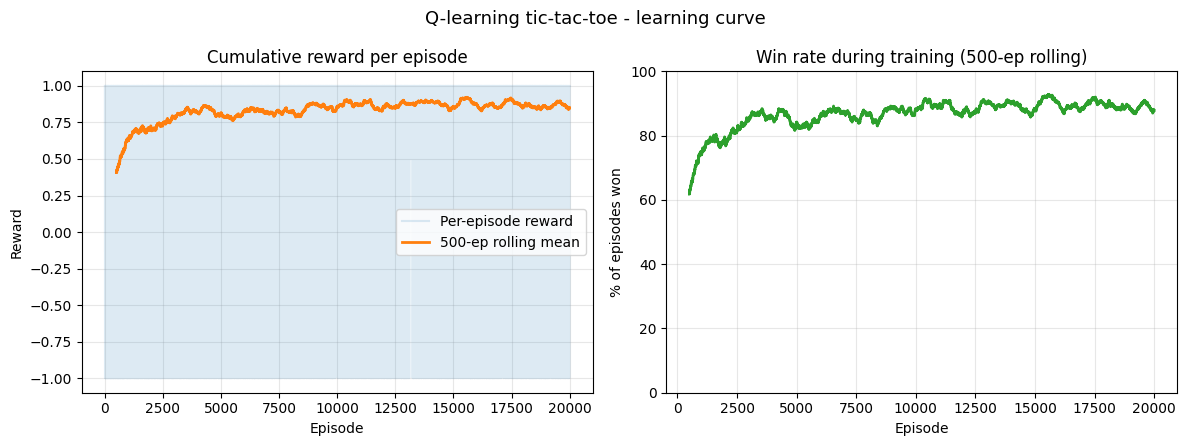

In [8]:
W = 500
roll_reward = np.convolve(train_rewards, np.ones(W) / W, mode='valid')
roll_winrate = np.convolve((train_outcomes == 1).astype(float),
                           np.ones(W) / W, mode='valid')

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

ax = axes[0]
ax.plot(train_rewards, alpha=0.15, label='Per-episode reward')
ax.plot(np.arange(W - 1, len(train_rewards)), roll_reward,
        linewidth=2, label=f'{W}-ep rolling mean')
ax.set_title('Cumulative reward per episode')
ax.set_xlabel('Episode'); ax.set_ylabel('Reward')
ax.legend(); ax.grid(True, alpha=0.3)

ax = axes[1]
ax.plot(np.arange(W - 1, len(train_outcomes)), 100 * roll_winrate,
        color='tab:green', linewidth=2)
ax.set_title(f'Win rate during training ({W}-ep rolling)')
ax.set_xlabel('Episode'); ax.set_ylabel('% of episodes won')
ax.set_ylim(0, 100); ax.grid(True, alpha=0.3)

plt.suptitle('Q-learning tic-tac-toe - learning curve', fontsize=13)
plt.tight_layout()
plt.show()

## Takeaways across paradigms

- **Supervised** needs paired `(X, y)` data. The fit objective is to minimize an error between the prediction and the known label. We evaluate against held-out labels via MSE / accuracy.
- **Unsupervised** sees only `X`. The 'fit' objective is structural - in K-means, minimize within-cluster squared distance. No held-out labels exist, so evaluation is either an internal metric (inertia, silhouette) or human interpretability.
- **Reinforcement** has no fixed dataset at all. The agent generates its own experience by interacting with an environment, and learns from scalar rewards. Evaluation looks at *behavior* (win rate, cumulative reward, episode length), not predictions.

The tic-tac-toe agent reaches ~98% win rate vs random play, but won't be optimal against a strong opponent - the random opponent rarely creates the positions where optimal play matters. Decaying epsilon and training via self-play (both sides learning) would close that gap.